In [2]:
import rebound
import matplotlib.pyplot as plt
import numpy as np

In [3]:
#helper values and functions

m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1


def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx


In [43]:
#non chaotic setup with astroid test particles (one group placed near ressonance and one group away from it)
sim = rebound.Simulation()
sim.integrator = "ias15"
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.202545,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=9.554841,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

ecc = [0.05,0.1,0.06,0.03,0.05,0.055]
ast_au = [2.05,2.1,2.0,3,2.8,2.75]

for i in range(6):
    rand_pomega = np.random.uniform(0, 2*np.pi)
    sim.add(m=0,a=ast_au[i],e=ecc[i],pomega=rand_pomega,inc=0)
    

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e6,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))
ast_e0 = []

for i in range(len(times)):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    long_peri_j[i] = sim.particles[1].pomega
    e_j[i] = sim.particles[1].e
    astr_eccs = [p.e for p in sim.particles[3:]]
    ast_e0.append(astr_eccs)


ast_e0 = np.array(ast_e0)

In [52]:
#chaotic with 2:1 MMr with astroid test particles (scattered all over)
sim = rebound.Simulation()
sim.integrator = "ias15"
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

ecc = [0.05,0.1,0.06,0.03,0.05,0.055]
ast_au = [2.05,2.1,2.0,3,2.8,2.75]


for i in range(6):
    rand_pomega = np.random.uniform(0, 2*np.pi)
    sim.add(m=0,a=ast_au[i],e=ecc[i],pomega =rand_pomega, inc=0)


sim.move_to_com()

times = np.linspace(0,1e6,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))
ast_e1 = []


for i in range(len(times)):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    long_peri_j[i] = sim.particles[1].pomega
    e_j[i] = sim.particles[2].e
    astr_eccs = [p.e for p in sim.particles[3:]]
    ast_e1.append(astr_eccs)

In [55]:
ast_e1 = np.array(ast_e1)

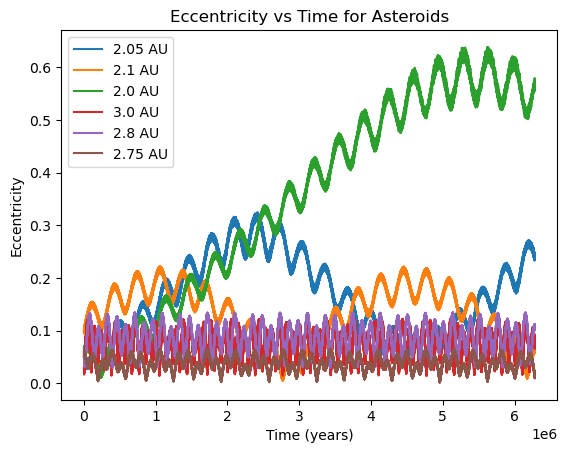

In [51]:
#graphing eccentricity vs time for the asteroind in the simulations without chaotic setup
plt.title('Eccentricity vs Time for Asteroids (Current J-S Locations)')
plt.plot(times, ast_e0[:,0],label = '2.05 AU')
plt.plot(times, ast_e0[:,1], label = '2.1 AU')
plt.plot(times, ast_e0[:,2], label = '2.0 AU')
plt.plot(times, ast_e0[:,3], label = '3.0 AU')
plt.plot(times, ast_e0[:,4], label = '2.8 AU')
plt.plot(times, ast_e0[:,5], label = '2.75 AU')
plt.xlabel('Time (years)')
plt.ylabel('Eccentricity')
plt.legend()
plt.show()

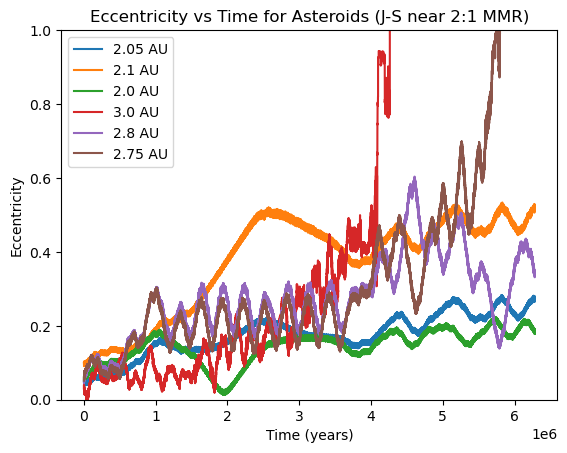

In [57]:
#graphing eccentricty vs time for the asteroids in the simulation with chaotic procession of the longitude of the perihelion
ast_au = [2.0,2.5,3,1.5,3.5,1.25]
plt.title('Eccentricity vs Time for Asteroids (J-S near 2:1 MMR)')
plt.plot(times, ast_e1[:,0],label = '2.05 AU')
plt.plot(times, ast_e1[:,1], label = '2.1 AU')
plt.plot(times, ast_e1[:,2], label = '2.0 AU')
plt.plot(times, ast_e1[:,3], label = '3.0 AU')
plt.plot(times, ast_e1[:,4], label = '2.8 AU')
plt.plot(times, ast_e1[:,5], label = '2.75 AU')
plt.xlabel('Time (years)')
plt.ylabel('Eccentricity')
plt.ylim(0,1)
plt.legend()
plt.show()